Aufgabe:
  Simuliere das Default-Verhalten von 1000 Obligoren (m=1000),
  jeder mit einer Default-Wahrscheinlichkeit von 1%.

  Zwei Szenarien:
    1) Unabhängige Defaults  (rho = 0)
    2) Korrelierte Defaults  (rho = 0.25)

  Jedes Szenario wird N=2000 mal simuliert.

Parameter:
  N   = 2000   -> Anzahl Simulationen
  m   = 1000   -> Anzahl Obligoren im Portfolio
  p   = 0.01   -> Default-Wahrscheinlichkeit jedes Obligors (1%)
  rho = 0.25   -> Asset-Korrelation (nur im korrelierten Szenario)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
np.random.seed(42)
N   = 2000
m   = 1000
p   = 0.01
rho = 0.25

In [3]:
#threshold with normal distribution at p = 0.01

d = norm.ppf(p)

print(d)

-2.3263478740408408


In [4]:
# Simulate independent defaults

X_independent = np.random.normal(0, 1, size=(N, m))
defaults_independent = X_independent < d
num_defaults_independent = defaults_independent.sum(axis=1)

print(num_defaults_independent)
print(num_defaults_independent.mean())
print(num_defaults_independent.std())

[ 6 12  8 ... 16 14 11]
10.1395
3.1755377103728435


In [5]:
# Simulate correlated defaults
F = np.random.normal(0, 1, size=(N, 1))
epsilon = np.random.normal(0, 1, size=(N, m))
X_correlated = rho * F + np.sqrt(1 - rho**2) * epsilon
defaults_correlated = X_correlated < d
num_defaults_correlated = defaults_correlated.sum(axis=1)

print(num_defaults_correlated)
print(num_defaults_correlated.mean())
print(num_defaults_correlated.std())

[0 9 6 ... 3 5 9]
9.974
7.855719190500638


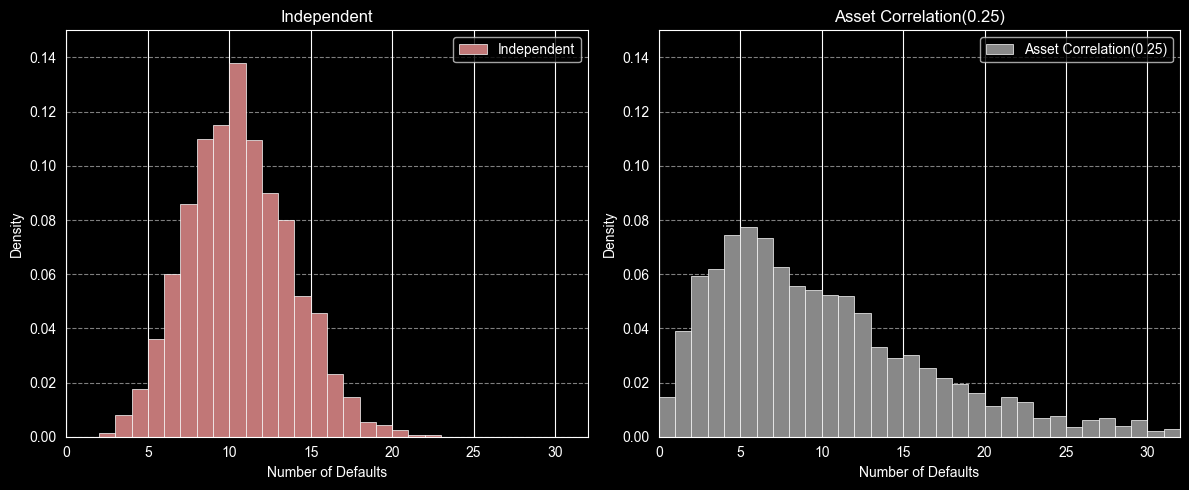

In [14]:
# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Linkes Histogramm: Unabhängig ---
axes[0].hist(
    num_defaults_independent,
    bins = np.arange(0, num_defaults_independent.max() + 2),
    density=True,
    color="#C17777",
    edgecolor="white",
    linewidth=0.5,
    label="Independent"
)
axes[0].set_title("Independent")
axes[0].set_xlabel("Number of Defaults")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].set_xlim(0, 32)
axes[0].set_ylim(0, 0.15)

# --- Rechtes Histogramm: Korreliert ---
axes[1].hist(
    num_defaults_correlated,
    bins = np.arange(0, num_defaults_correlated.max()  + 2),
    density=True,
    color="#888888",
    edgecolor="white",
    linewidth=0.5,
    label="Asset Correlation(0.25)"
)
axes[1].set_title("Asset Correlation(0.25)")
axes[1].set_xlabel("Number of Defaults")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].set_xlim(0, 32)
axes[1].set_ylim(0, 0.15)

plt.tight_layout()
plt.show()